### Import Libraries

In [100]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import json, csv

import warnings
warnings.filterwarnings('ignore')

import pickle

from sklearn.model_selection import StratifiedKFold, KFold, cross_validate
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import GridSearchCV
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import shap
from sklearn.inspection import permutation_importance

### Load the Data

In [101]:
JSON = 'dataset_realestateComAu.json'
CSV = 'dataset_realestateComAu_filtered.csv'

KEEP_FIELDS = [
    "title", "price", "description", "propertyType", "dateSold",
    "landSize", "address", "generalFeatures", "propertyFeatures"
]


with open(JSON, "r", encoding="utf-8") as f:
    data = json.load(f)

filtered = []
for item in data:
    new = {k: item.get(k) for k in KEEP_FIELDS}
    filtered.append(new)

rows = []
for item in filtered:
    row = {}

    row['title'] = item.get('title')
    row['description'] = item.get('description')
    row['propertyType'] = item.get('propertyType')

    price = item.get("price") or {}
    row["price"] = price.get("display")

    sold_date = item.get("dateSold") or {}
    row["dateSold"] = sold_date.get("value")

    land = item.get("landSize") or {}
    row["landSize"] = land.get("value")

    address = item.get("address") or {}
    row["suburb"] = address.get("suburb")
    row["postCode"] = address.get("postcode")
    location = address.get("location") or {}
    row["latitude"] = location.get("latitude")
    row["longitude"] = location.get("longitude")

    general = item.get("generalFeatures") or {}
    bedrooms = general.get("bedrooms") or {}
    bathrooms = general.get("bathrooms") or {}
    parking = general.get("parkingSpaces") or {}
    row["bedrooms"] = bedrooms.get("value")
    row["bathrooms"] = bathrooms.get("value")
    row["parkingSpaces"] = parking.get("value")

    property_features = item.get("propertyFeatures") or []
    flat_sections = []
    outdoor_count = 0
    indoor_count = 0
    total_features = 0

    for section in (property_features):
        sec = (section.get("section") or section.get("label") or "other")
        feats = section.get("features") or []
        # count numeric features in this section
        n = len(feats)
        total_features += n
        sec_key = str(sec).strip().lower()
        if "outdoor" in sec_key:
            outdoor_count += n
        elif "indoor" in sec_key:
            indoor_count += n

    # numeric features to use for modeling
    row["outdoorFeatures"] = outdoor_count
    row["indoorFeatures"] = indoor_count
    row["totalFeatures"] = total_features

    rows.append(row)

df = pd.DataFrame(rows)
df.to_csv(CSV, index=False, quoting=csv.QUOTE_ALL, encoding="utf-8")

print(f"Wrote safe CSV -> {CSV}")

Wrote safe CSV -> dataset_realestateComAu_filtered.csv


In [102]:
display(df.head(5))
print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())

,title,description,propertyType,price,dateSold,landSize,suburb,postCode,latitude,longitude,bedrooms,bathrooms,parkingSpaces,outdoorFeatures,indoorFeatures,totalFeatures
0,Family Luxury On A Grand Scale,"Impressive from first glance, appealing to the...",house,"$3,815,000",2025-09-13,829.0,Surrey Hills,3127,-37.828001,145.097549,5,3,3.0,2,1,3
1,A Dream to Call Home,At the end of a quiet court in a secluded vill...,house,"$2,446,000",2025-09-13,339.0,Balwyn,3103,-37.804014,145.081627,4,2,2.0,2,5,7
2,GENEROUS 725m2 ALLOTMENT WITH PREFERRED NORTH/...,*No Heritage Overlay*<br/><br/>This substantia...,house,"$2,160,000",2025-09-13,725.0,Camberwell,3124,-37.841144,145.092189,3,2,2.0,3,9,12
3,Modern Family Excellence In Quiet Cul-de-sac S...,Peacefully positioned in an exclusive cul-de-s...,house,"$1,692,000",2025-09-13,473.0,Burwood,3125,-37.858181,145.109191,5,2,2.0,1,0,1
4,Classic Family Home Drenched in Charm,"Set in a desirable area of Burwood, this gorge...",house,"$1,625,000",2025-09-13,438.0,Burwood,3125,-37.848369,145.098845,3,2,2.0,1,0,1


Dataset shape: (2000, 16)
Columns: ['title', 'description', 'propertyType', 'price', 'dateSold', 'landSize', 'suburb', 'postCode', 'latitude', 'longitude', 'bedrooms', 'bathrooms', 'parkingSpaces', 'outdoorFeatures', 'indoorFeatures', 'totalFeatures']


### Explore missing values in the dataset

In [103]:
print("Dataset missing values summary: ")
print(df.isnull().sum())

Dataset missing values summary: 
title                0
description          0
propertyType         0
price                0
dateSold             0
landSize           737
suburb               0
postCode             0
latitude             2
longitude            2
bedrooms             0
bathrooms            0
parkingSpaces       28
outdoorFeatures      0
indoorFeatures       0
totalFeatures        0
dtype: int64


In [104]:
cols_to_drop = df.columns[
    df.isnull().mean() > 0.4
].tolist()
df = df.drop(columns=cols_to_drop)

print("New dataframe shape:", df.shape)
display(df.head(5))

New dataframe shape: (2000, 16)


,title,description,propertyType,price,dateSold,landSize,suburb,postCode,latitude,longitude,bedrooms,bathrooms,parkingSpaces,outdoorFeatures,indoorFeatures,totalFeatures
0,Family Luxury On A Grand Scale,"Impressive from first glance, appealing to the...",house,"$3,815,000",2025-09-13,829.0,Surrey Hills,3127,-37.828001,145.097549,5,3,3.0,2,1,3
1,A Dream to Call Home,At the end of a quiet court in a secluded vill...,house,"$2,446,000",2025-09-13,339.0,Balwyn,3103,-37.804014,145.081627,4,2,2.0,2,5,7
2,GENEROUS 725m2 ALLOTMENT WITH PREFERRED NORTH/...,*No Heritage Overlay*<br/><br/>This substantia...,house,"$2,160,000",2025-09-13,725.0,Camberwell,3124,-37.841144,145.092189,3,2,2.0,3,9,12
3,Modern Family Excellence In Quiet Cul-de-sac S...,Peacefully positioned in an exclusive cul-de-s...,house,"$1,692,000",2025-09-13,473.0,Burwood,3125,-37.858181,145.109191,5,2,2.0,1,0,1
4,Classic Family Home Drenched in Charm,"Set in a desirable area of Burwood, this gorge...",house,"$1,625,000",2025-09-13,438.0,Burwood,3125,-37.848369,145.098845,3,2,2.0,1,0,1


### Imputation of missing values

In [105]:
print("Data type of each feature in X:")
print(df.dtypes)

Data type of each feature in X:
title               object
description         object
propertyType        object
price               object
dateSold            object
landSize           float64
suburb              object
postCode            object
latitude           float64
longitude          float64
bedrooms             int64
bathrooms            int64
parkingSpaces      float64
outdoorFeatures      int64
indoorFeatures       int64
totalFeatures        int64
dtype: object


In [106]:
# Check skewness of features with numerical data types
missing_features = [
    'landSize', 'latitude', 'longitude', 'parkingSpaces'
]

print("Skewness of features:")
df[missing_features] = df[missing_features].apply(pd.to_numeric, errors='coerce')
skewness = df[missing_features].skew().round(5)

print(skewness)

Skewness of features:
landSize         0.31063
latitude         0.37408
longitude       -0.36921
parkingSpaces    2.76244
dtype: float64


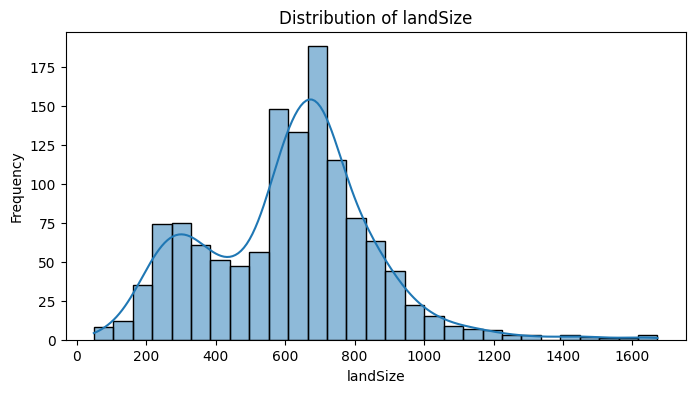

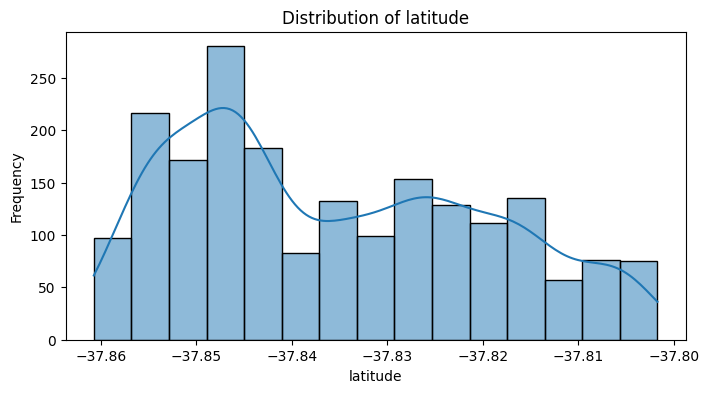

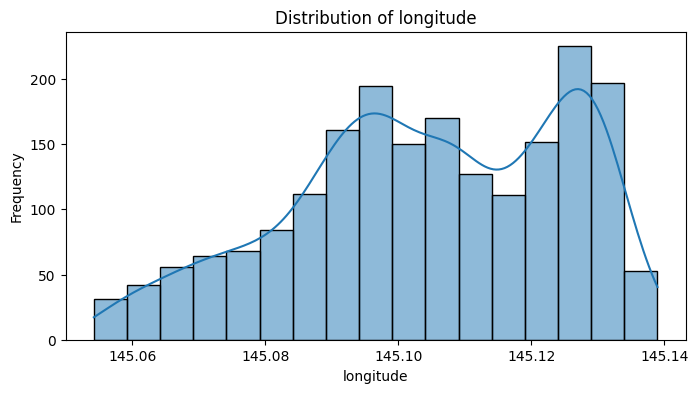

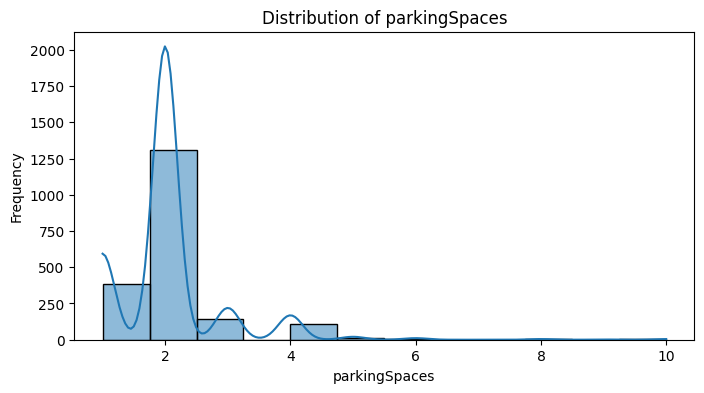

In [107]:
for c in missing_features:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[c].dropna(), kde=True)
    plt.title(f'Distribution of {c}')
    plt.xlabel(c)
    plt.ylabel('Frequency')
    plt.show()

In [108]:
for c in missing_features:
    s = skewness[c]
    if abs(s) > 1.0:
            method = 'median'
            val = df[c].median()
    else:
        method = 'mean'
        val = df[c].mean()
    df[c] = df[c].fillna(val)
    print(f"Imputed {c} with {method} = {val}")

Imputed landSize with mean = 612.3119556611243
Imputed latitude with mean = -37.83567504947174
Imputed longitude with mean = 145.1043455914867
Imputed parkingSpaces with median = 2.0


### Convert Data Types

In [109]:
print(df.dtypes)

title               object
description         object
propertyType        object
price               object
dateSold            object
landSize           float64
suburb              object
postCode            object
latitude           float64
longitude          float64
bedrooms             int64
bathrooms            int64
parkingSpaces      float64
outdoorFeatures      int64
indoorFeatures       int64
totalFeatures        int64
dtype: object


In [110]:
# get raw price column (use original column to avoid earlier coercion to NaN)
raw = df.get('price')

# clean currency strings and convert to numeric
cleaned = raw.astype(str).str.replace(r'[^0-9.]', '', regex=True)  # removes $, commas, spaces, etc.
df['price'] = pd.to_numeric(cleaned, errors='coerce').rename('price')

# convert float to int
df['parkingSpaces'] = pd.to_numeric(df['parkingSpaces'], downcast='integer')

### Create new features

In [111]:
def haversine(lat1, lon1, lat2, lon2):
    # returns kilometers
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
    dlat = lat2 - lat1; dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a))

# example: choose CBD coords (replace with city center)
cbd_lat, cbd_lon = -37.810272, 144.962646
df['distanceToCBD'] = haversine(df['latitude'], df['longitude'], cbd_lat, cbd_lon)

In [112]:
from sklearn.neighbors import NearestNeighbors

coords = df[['latitude','longitude']].to_numpy()
nbrs = NearestNeighbors(n_neighbors=2, algorithm='ball_tree').fit(np.radians(coords))
dist_rad, idx = nbrs.kneighbors(np.radians(coords))
# dist_rad in radians on unit sphere -> convert to km:
df['distanceToNearest'] = dist_rad[:,1] * 6371.0

In [113]:
df['dateSold'] = pd.to_datetime(df['dateSold'], errors='coerce')
df['soldYear'] = df['dateSold'].dt.year
df['soldMonth'] = df['dateSold'].dt.month
df['soldWeekday'] = df['dateSold'].dt.weekday

df['bedBathRatio'] = df['bedrooms'] / df['bathrooms'].replace(0, np.nan)

In [114]:
print("Final feature matrix shape:", df.shape)
display(df.head(3))

Final feature matrix shape: (2000, 22)


,title,description,propertyType,price,dateSold,landSize,suburb,postCode,latitude,longitude,...,parkingSpaces,outdoorFeatures,indoorFeatures,totalFeatures,distanceToCBD,distanceToNearest,soldYear,soldMonth,soldWeekday,bedBathRatio
0,Family Luxury On A Grand Scale,"Impressive from first glance, appealing to the...",house,3815000,2025-09-13,829.0,Surrey Hills,3127,-37.828001,145.097549,...,3,2,1,3,12.012536,0.039644,2025,9,5,1.666667
1,A Dream to Call Home,At the end of a quiet court in a secluded vill...,house,2446000,2025-09-13,339.0,Balwyn,3103,-37.804014,145.081627,...,2,2,5,7,10.475942,0.021436,2025,9,5,2.000000
2,GENEROUS 725m2 ALLOTMENT WITH PREFERRED NORTH/...,*No Heritage Overlay*<br/><br/>This substantia...,house,2160000,2025-09-13,725.0,Camberwell,3124,-37.841144,145.092189,...,2,3,9,12,11.884423,0.090112,2025,9,5,1.500000


### Housing price distribution

In [115]:
print("dtype:", df['price'].dtype, "shape:", df['price'].shape)
print("non-null count`:", int(df['price'].notna().sum()))
print("n_unique:", int(df['price'].nunique(dropna=True)))
print(df['price'].describe().to_string())


dtype: int64 shape: (2000,)
non-null count`: 2000
n_unique: 947
count    2.000000e+03
mean     1.715762e+06
std      7.752281e+05
min      1.680000e+05
25%      1.197500e+06
50%      1.530250e+06
75%      2.066500e+06
max      7.050000e+06


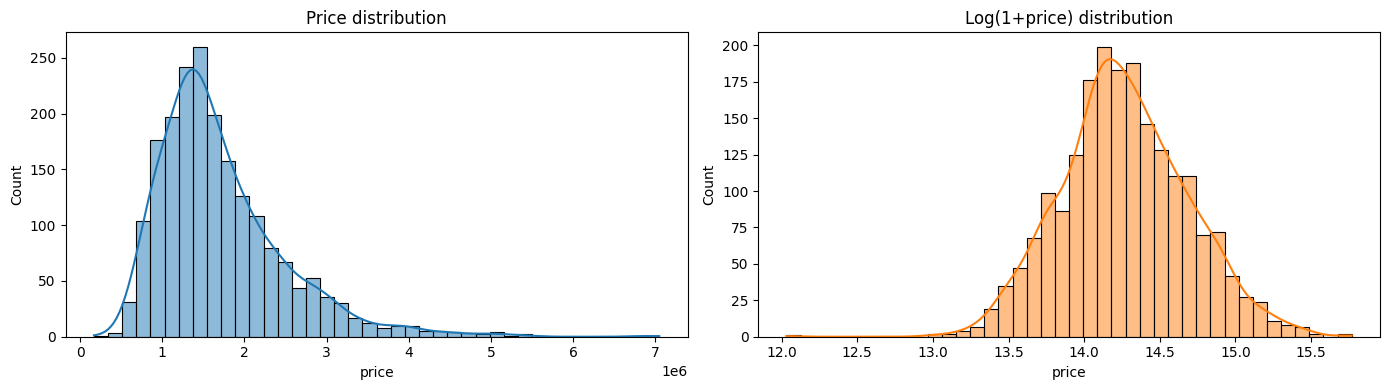

In [116]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['price'], bins=40, kde=True, ax=axes[0], color='C0')
axes[0].set_title('Price distribution')
sns.histplot(np.log1p(df['price']), bins=40, kde=True, ax=axes[1], color='C1')
axes[1].set_title('Log(1+price) distribution')
plt.tight_layout()
plt.show()

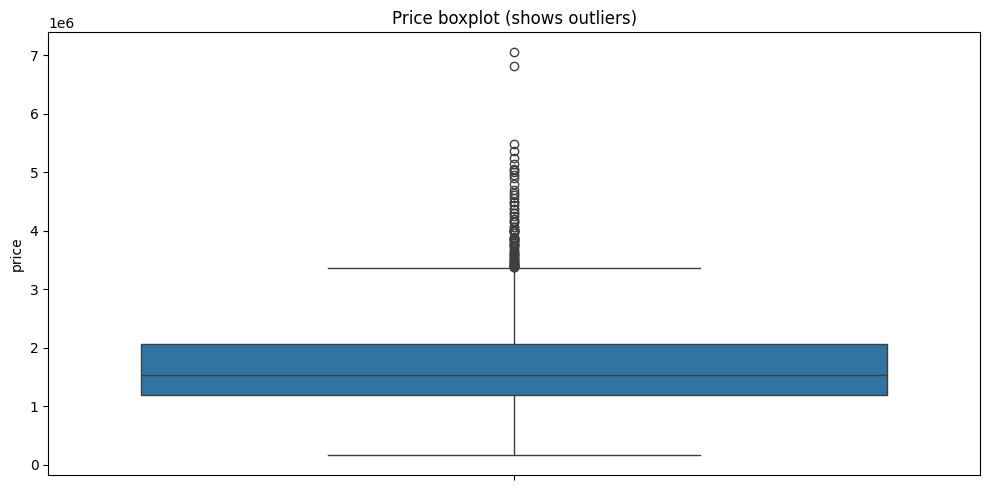

In [117]:
plt.figure(figsize=(10, 5))
sns.boxplot(df['price'])
plt.title('Price boxplot (shows outliers)')
plt.tight_layout()
plt.show()

### Price trends overtime

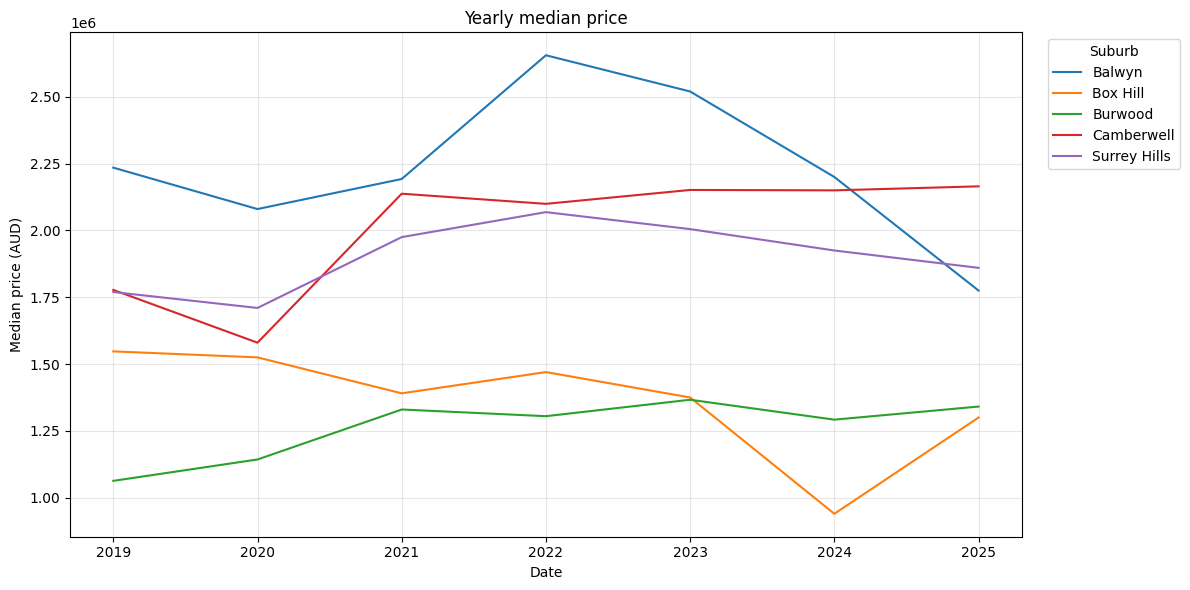

In [118]:
yearly = df.groupby(['soldYear', 'suburb'])['price'].median().reset_index()
pivot = yearly.pivot(index='soldYear', columns='suburb', values='price')

plt.figure(figsize=(12,6))
for col in pivot.columns:
    plt.plot(pivot.index, pivot[col], label=col)
plt.grid(True, alpha=0.3)
plt.legend(title='Suburb', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.title(f'Yearly median price')
plt.xlabel('Date')
plt.ylabel('Median price (AUD)')
plt.tight_layout()
plt.show()

### Define features and target variable

In [119]:
clean_df = df.drop(columns=['dateSold', 'title', 'description'])
X = clean_df.drop(columns=['price'])
y = clean_df['price']

print("Feature matrix X shape:", X.shape)
print("Target variable y shape:", y.shape)

Feature matrix X shape: (2000, 18)
Target variable y shape: (2000,)


In [120]:
print(X.columns.tolist())

['propertyType', 'landSize', 'suburb', 'postCode', 'latitude', 'longitude', 'bedrooms', 'bathrooms', 'parkingSpaces', 'outdoorFeatures', 'indoorFeatures', 'totalFeatures', 'distanceToCBD', 'distanceToNearest', 'soldYear', 'soldMonth', 'soldWeekday', 'bedBathRatio']


### Train-test split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape:", X_test.shape, y_test.shape)


Training set shape: (1600, 18) (1600,)
Testing set shape: (400, 18) (400,)


In [122]:
cat_features = ['propertyType', 'postCode', 'suburb']

# Display unique values for each categorical features to determine encoding techniques
unique = {col: pd.Series(X_train[col].unique()) for col in cat_features}
unique_df = pd.DataFrame(unique)
unique_df = unique_df.fillna('')

display(unique_df)

,propertyType,postCode,suburb
0,townhouse,3125,Burwood
1,house,3124,Camberwell
2,other,3127,Surrey Hills
3,,3128,Box Hill
4,,3103,Balwyn


In [123]:
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# fit on training categoricals and get dense arrays
X_train_ohe = one_hot_encoder.fit_transform(X_train[cat_features])
X_train_ohe = np.asarray(X_train_ohe)  # ensure dense numpy array

# build DataFrame for encoded cols, preserve index
X_train_ohe_df = pd.DataFrame(
    X_train_ohe,
    columns=one_hot_encoder.get_feature_names_out(cat_features),
    index=X_train.index
)

# concat (drop original categorical cols)
X_train_pre = pd.concat([X_train.drop(columns=cat_features), X_train_ohe_df], axis=1)

# transform test set
X_test_ohe = one_hot_encoder.transform(X_test[cat_features])
X_test_ohe = np.asarray(X_test_ohe)
X_test_ohe_df = pd.DataFrame(
    X_test_ohe,
    columns=one_hot_encoder.get_feature_names_out(cat_features),
    index=X_test.index
)
X_test_pre = pd.concat([X_test.drop(columns=cat_features), X_test_ohe_df], axis=1)

In [124]:
# Normalize/scale numeric features
num_features = [
    'landSize', 'latitude', 'longitude', 'parkingSpaces',
    'distanceToCBD', 'distanceToNearest',
    'bedrooms', 'bathrooms', 'bedBathRatio',
    'outdoorFeatures', 'indoorFeatures', 'totalFeatures'
]

scaler = StandardScaler()

X_train_pre[num_features] = scaler.fit_transform(X_train_pre[num_features])
X_test_pre[num_features] = scaler.transform(X_test_pre[num_features])

In [125]:
print("Training set shape:", X_train_pre.shape, y_train.shape)
print("Testing set shape:", X_test_pre.shape, y_test.shape)

Training set shape: (1600, 28) (1600,)
Testing set shape: (400, 28) (400,)


### Define functions for score and cross-validation

In [126]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
scoring = {'mae': 'neg_mean_absolute_error'}
test_results = {}

### Ridge

In [127]:
ridge = Ridge()
ridge_grid = {'alpha': [1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}

ridge_regressor = GridSearchCV(
    ridge, ridge_grid, 
    cv=kf, scoring='neg_mean_absolute_error', 
    n_jobs=-1
    )
ridge_regressor.fit(X_train_pre, y_train)

,estimator,Ridge()
,param_grid,"{'alpha': [1e-15, 1e-10, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1e-15


In [128]:
best_ridge = Ridge(**ridge_regressor.best_params_, random_state=42)
cv_res = cross_validate(best_ridge, X_train_pre, y_train, cv=kf,
                        scoring=scoring, return_train_score=True, n_jobs=-1)

In [129]:
train_mae = -np.mean(cv_res['train_mae'])
test_mae  = -np.mean(cv_res['test_mae'])

print("Cross-validation performance (Ridge Regression):")
print(f"CV (train)   MAE: {train_mae:.2f}")
print(f"CV (valid)   MAE: {test_mae:.2f}")

Cross-validation performance (Ridge Regression):
CV (train)   MAE: 301281.89
CV (valid)   MAE: 306550.33


In [130]:
best_ridge.fit(X_train_pre, y_train_log)
pred_log = best_ridge.predict(X_test_pre)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

test_results['Ridge'] = {
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
}

print("Hold-out test set performance:")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2  : {r2:.4f}")

Hold-out test set performance:
MAE : 270487.53
RMSE: 434097.19
R2  : 0.7046


### Lasso

In [131]:
lasso = Lasso()
lasso_grid = {'alpha': [1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100]}

lasso_regressor = GridSearchCV(
    lasso, lasso_grid, 
    cv=kf, scoring='neg_mean_absolute_error', 
    n_jobs=-1
    )
lasso_regressor.fit(X_train_pre, y_train)

,estimator,Lasso()
,param_grid,"{'alpha': [1e-15, 1e-10, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1e-15


In [132]:
best_lasso = Lasso(**lasso_regressor.best_params_, random_state=42)
cv_res = cross_validate(best_lasso, X_train_pre, y_train, cv=kf,
                        scoring=scoring, return_train_score=True, n_jobs=-1)

In [133]:
train_mae = -np.mean(cv_res['train_mae'])
test_mae  = -np.mean(cv_res['test_mae'])

print("Cross-validation performance (Lasso Regression):")
print(f"CV (train)   MAE: {train_mae:.2f}")
print(f"CV (valid)   MAE: {test_mae:.2f}")

Cross-validation performance (Lasso Regression):
CV (train)   MAE: 301349.66
CV (valid)   MAE: 307465.56


In [134]:
best_lasso.fit(X_train_pre, y_train)
y_pred = best_lasso.predict(X_test_pre)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

test_results['Lasso'] = {
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
}

print("Hold-out test set performance:")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2  : {r2:.4f}")

Hold-out test set performance:
MAE : 344136.80
RMSE: 544836.13
R2  : 0.5346


### ElasticNet

In [135]:
elastic_net = ElasticNet()
elastic_net_grid = {
    'alpha': [1e-15,1e-10,1e-8,1e-3,1e-2,1,5,10,20,30,35,40,45,50,55,100],
    'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]
}
elastic_net_regressor = GridSearchCV(
    elastic_net, elastic_net_grid, 
    cv=kf, scoring='neg_mean_absolute_error', 
    n_jobs=-1
    )
elastic_net_regressor.fit(X_train_pre, y_train)

,estimator,ElasticNet()
,param_grid,"{'alpha': [1e-15, 1e-10, ...], 'l1_ratio': [0.1, 0.3, ...]}"
,scoring,'neg_mean_absolute_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,alpha,1


In [136]:
best_elastic_net = ElasticNet(**elastic_net_regressor.best_params_)
cv_res = cross_validate(best_elastic_net, X_train_pre, y_train, cv=kf,
                        scoring=scoring, return_train_score=True, n_jobs=-1)

In [137]:
train_mae = -np.mean(cv_res['train_mae'])
test_mae  = -np.mean(cv_res['test_mae'])

print("Cross-validation performance (ElasticNet Regression):")
print(f"CV (train)   MAE: {train_mae:.2f}")
print(f"CV (valid)   MAE: {test_mae:.2f}")

Cross-validation performance (ElasticNet Regression):
CV (train)   MAE: 303558.16
CV (valid)   MAE: 307180.57


In [138]:
best_elastic_net.fit(X_train_pre, y_train)
y_pred = best_elastic_net.predict(X_test_pre)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

test_results['ElasticNet'] = {
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
}

print("Hold-out test set performance:")
print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2  : {r2:.4f}")

Hold-out test set performance:
MAE : 335497.30
RMSE: 515227.09
R2  : 0.5838


### XGBoost

In [139]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
optuna.logging.disable_default_handler()

In [140]:
def objective(trial):
    params = {
        'learning_rate': trial.suggest_loguniform('learning_rate', 0.01, 0.2),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'n_estimators': trial.suggest_categorical('n_estimators', [100, 200, 500]),
        'objective': 'reg:squarederror',
        'random_state': 42,
        'verbosity': 0
    }
    model = xgb.XGBRegressor(**params)
    cv_res = cross_validate(
        model, 
        X_train_pre, y_train, 
        cv=kf, 
        scoring=scoring,
        n_jobs=-1
        )
    mean_mae = -np.mean(cv_res['test_mae'])
    return mean_mae

In [141]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

print('Best MAE (cv):', study.best_value)
print('Best params:', study.best_params)

Best trial: 13. Best value: 229914: 100%|██████████| 30/30 [00:17<00:00,  1.73it/s]

Best MAE (cv): 229914.04375
Best params: {'learning_rate': 0.029149467477405225, 'max_depth': 8, 'min_child_weight': 8, 'subsample': 0.6133463143179324, 'colsample_bytree': 0.40716811176902806, 'n_estimators': 500}


In [142]:
# retrain best model and evaluate on holdout
best_xgb = xgb.XGBRegressor(**study.best_params, objective='reg:squarederror', random_state=42, verbosity=0)
best_xgb.fit(X_train_pre, y_train)

y_pred = best_xgb.predict(X_test_pre)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

test_results['XGBoost'] = {
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
}

print('Hold-out test set performance:')
print(f'MAE : {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2  : {r2:.4f}')

Hold-out test set performance:
MAE : 260059.45
RMSE: 425963.59
R2  : 0.7155


### LightGBM (Light Gradient Boosting Machine) 

In [143]:
def gbm_objective(trial):
    params = {
        "learning_rate": trial.suggest_loguniform("learning_rate", 0.01, 1.0),
        "n_estimators": trial.suggest_categorical("n_estimators", [200, 500, 1000]),
        "max_depth": trial.suggest_int("max_depth", 5, 20),
        "num_leaves": trial.suggest_int("num_leaves", 16, 512),
        "max_bin": trial.suggest_int("max_bin", 63, 512),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 0, 10),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "lambda_l1": trial.suggest_loguniform("lambda_l1", 1e-8, 10.0),
        "lambda_l2": trial.suggest_loguniform("lambda_l2", 1e-8, 10.0),
        "extra_trees": True,
        "boosting_type": "dart",
        "random_state": 42,
        "verbosity": -1,
        "n_jobs": -1,
    }

    model = lgb.LGBMRegressor(**params)

    cv_res = cross_validate(
        model, 
        X_train_pre, y_train, 
        cv=kf,
        scoring=scoring,
        n_jobs=-1
        )
    
    mean_mae = -np.mean(cv_res['test_mae'])
    
    return mean_mae

In [144]:
study = optuna.create_study(direction='minimize')
study.optimize(gbm_objective, n_trials=30, show_progress_bar=True)

print('Best MAE (cv):', study.best_value)
print('Best params:', study.best_params)

Best trial: 26. Best value: 235896: 100%|██████████| 30/30 [05:48<00:00, 11.61s/it]

Best MAE (cv): 235895.76911860876
Best params: {'learning_rate': 0.11428811998661856, 'n_estimators': 1000, 'max_depth': 18, 'num_leaves': 490, 'max_bin': 429, 'bagging_fraction': 0.9586317555537895, 'bagging_freq': 9, 'feature_fraction': 0.9363561767765589, 'lambda_l1': 0.0034449999472227362, 'lambda_l2': 0.9561652148438214}


In [145]:
# retrain best model and evaluate on holdout
best_lgb = lgb.LGBMRegressor(**study.best_params, **{
    "extra_trees": True,
    "boosting_type": "dart",
    "random_state": 42,
})
best_lgb.fit(X_train_pre, y_train)

y_pred = best_lgb.predict(X_test_pre)
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

test_results['LightGBM'] = {
    'MAE': mae,
    'RMSE': rmse,
    'R2': r2
}

print('Hold-out test set performance:')
print(f'MAE : {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R2  : {r2:.4f}')

[LightGBM] [Warning] feature_fraction is set=0.9363561767765589, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9363561767765589
[LightGBM] [Warning] lambda_l1 is set=0.0034449999472227362, reg_alpha=0.0 will be ignored. Current value: lambda_l1=0.0034449999472227362
[LightGBM] [Warning] lambda_l2 is set=0.9561652148438214, reg_lambda=0.0 will be ignored. Current value: lambda_l2=0.9561652148438214
[LightGBM] [Warning] bagging_fraction is set=0.9586317555537895, subsample=1.0 will be ignored. Current value: bagging_fraction=0.9586317555537895
[LightGBM] [Warning] bagging_freq is set=9, subsample_freq=0 will be ignored. Current value: bagging_freq=9
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] feature_fraction is set=0.9363561767765589, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9363561767765589
[LightGBM] [Warning] lambda_l1 is set=0.0034449999472227362, reg_alpha=0.0 will be i

### Model evaluation comparison

In [146]:
result_df = pd.DataFrame(test_results).T
result_df.index.name = 'Model'
result_df.reset_index(inplace=True)
display(result_df.round(4).sort_values(by='R2'))

,Model,MAE,RMSE,R2
1,Lasso,344136.8012,544836.1258,0.5346
2,ElasticNet,335497.2988,515227.0912,0.5838
4,LightGBM,268278.0295,442388.5746,0.6932
0,Ridge,270487.5298,434097.1911,0.7046
3,XGBoost,260059.4531,425963.5938,0.7155


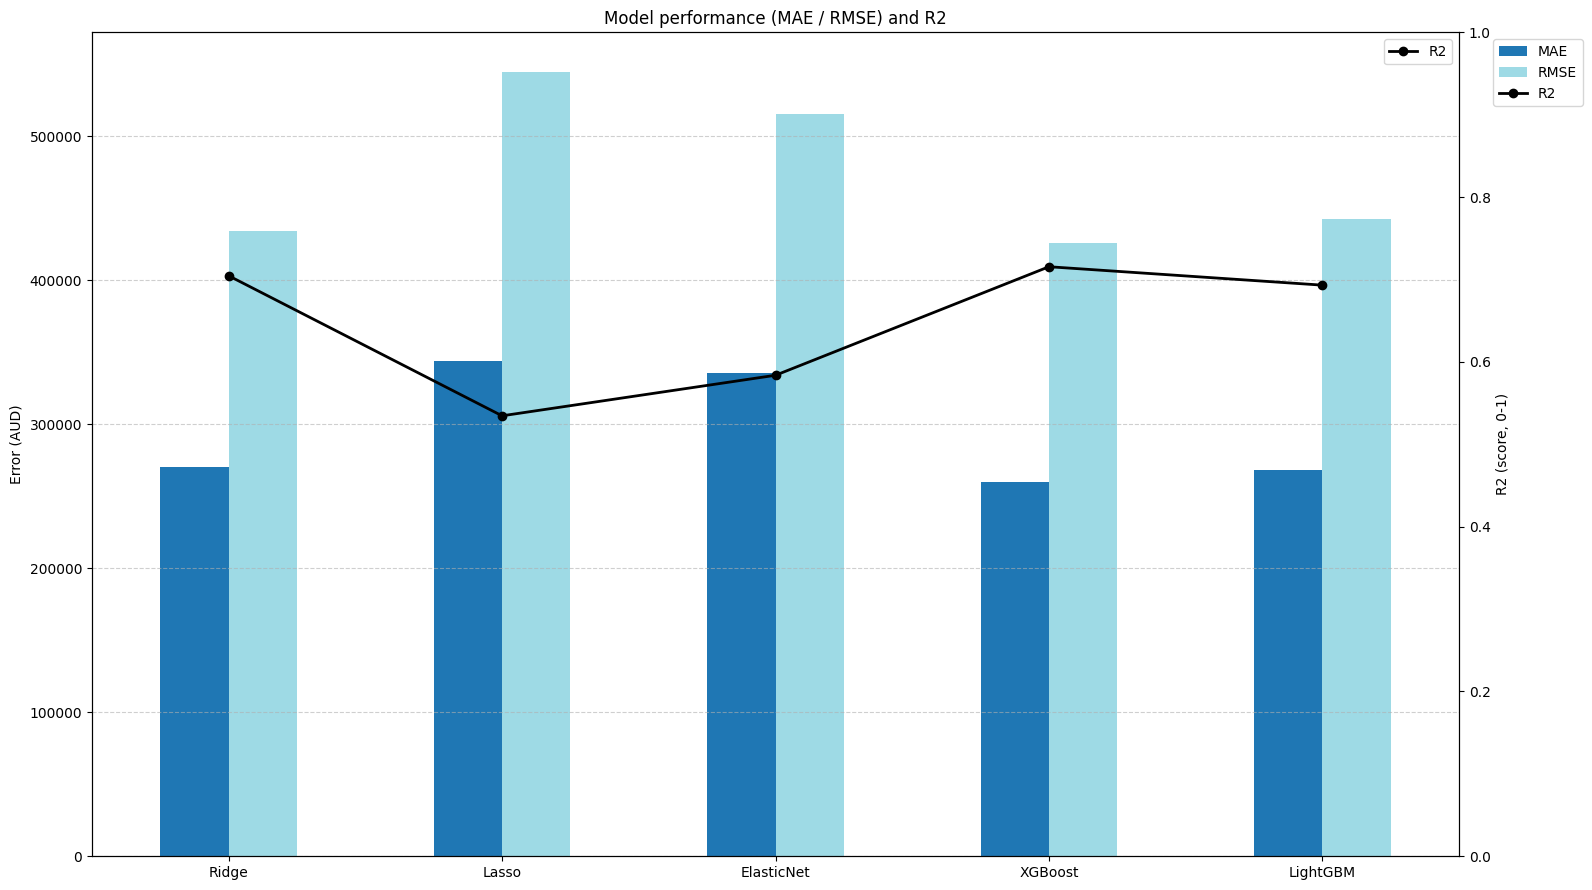

In [147]:
fig, ax = plt.subplots(figsize=(16, 9))

result_df[['MAE', 'RMSE']].plot(kind='bar', ax=ax, width=0.5, colormap='tab20', legend=True)

ax.set_ylabel('Error (AUD)')
ax.set_title("Model performance (MAE / RMSE) and R2")
ax.set_xticklabels(result_df['Model'], rotation=0)

ax2 = ax.twinx()
result_df['R2'].plot(kind='line', marker='o', color='black', linewidth=2, ax=ax2, legend=True)
ax2.set_ylabel('R2 (score, 0-1)')
ax2.set_ylim(0, 1)  # optional clamp for clarity

# combined legend
lines, labels = ax.get_legend_handles_labels()
line2, label2 = ax2.get_legend_handles_labels()
ax.legend(lines + line2, labels + label2, loc='upper left', bbox_to_anchor=(1.02,1))

ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Feature importance

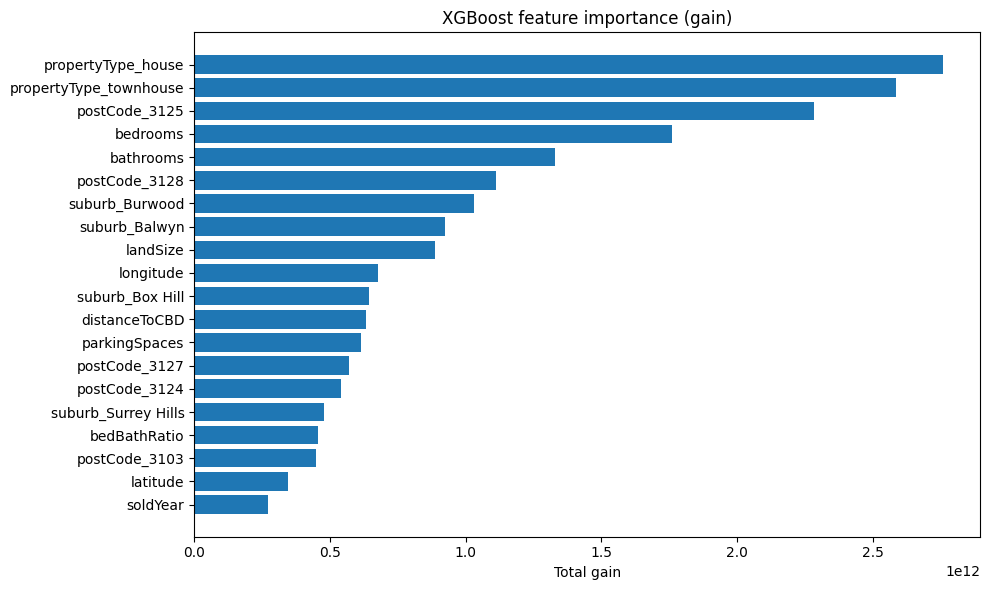

,gain,weight,cover,gain_norm
propertyType_house,2.756545e+12,189.0,202.799,0.127
propertyType_townhouse,2.586435e+12,158.0,235.348,0.119
postCode_3125,2.282455e+12,201.0,132.020,0.105
bedrooms,1.758176e+12,678.0,310.593,0.081
bathrooms,1.330505e+12,689.0,301.747,0.061
postCode_3128,1.113301e+12,129.0,153.713,0.051
suburb_Burwood,1.030837e+12,87.0,136.506,0.048
suburb_Balwyn,9.240495e+11,70.0,149.886,0.043
landSize,8.865462e+11,1945.0,261.578,0.041
longitude,6.774249e+11,2184.0,194.825,0.031


In [159]:
booster = best_xgb.get_booster()

gain_dict  = booster.get_score(importance_type='gain')
weight_dict= booster.get_score(importance_type='weight')
cover_dict = booster.get_score(importance_type='cover')

cols = list(X_train_pre.columns)

def map_keys(d, columns):
    mapped = {}
    for k, v in d.items():
        if isinstance(k, str) and k.startswith('f'):
            try:
                idx = int(k[1:])
                fname = columns[idx]
            except Exception:
                fname = k
        else:
            fname = k
        mapped[fname] = v
    return mapped

gain_m   = map_keys(gain_dict, cols)
weight_m = map_keys(weight_dict, cols)
cover_m  = map_keys(cover_dict, cols)

imp_df = pd.DataFrame({
    'gain': pd.Series(gain_m),
    'weight': pd.Series(weight_m),
    'cover': pd.Series(cover_m),
}).fillna(0.0)

# sort and normalize (optional)
imp_df = imp_df.sort_values('gain', ascending=False)
imp_df['gain_norm'] = imp_df['gain'] / imp_df['gain'].sum()

# horizontal bar plot of top 20 by gain
top = imp_df.head(20).iloc[::-1]
plt.figure(figsize=(10,6))
plt.barh(top.index, top['gain'], color='C0')
plt.xlabel('Total gain')
plt.title('XGBoost feature importance (gain)')
plt.tight_layout()
plt.show()

display(imp_df.head(10).round(3))

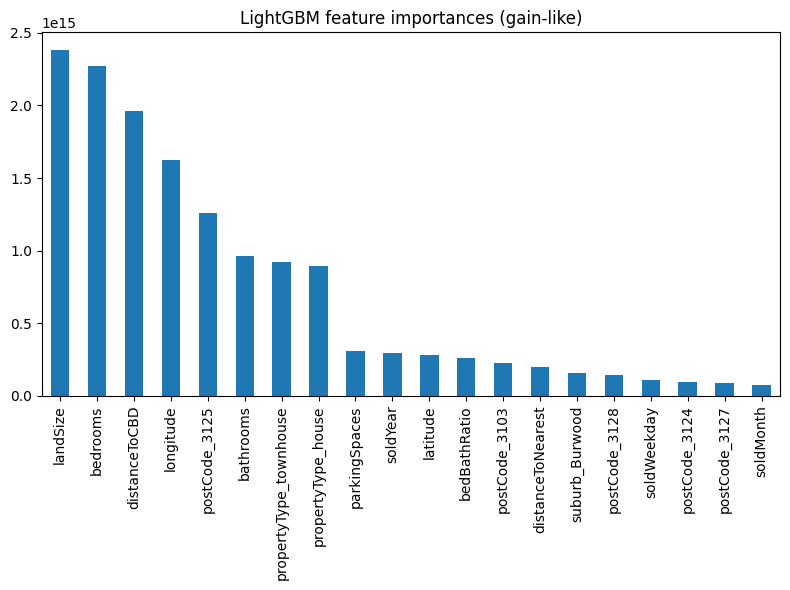

In [ ]:
# 2) LightGBM built-in importances (if LGB model available)
booster = getattr(best_lgb, "booster_", None)
gains = booster.feature_importance(importance_type='gain')
importances_lgb = pd.Series(gains, index=X_train_pre.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
importances_lgb.head(20).plot.bar()
plt.title("LightGBM feature importances (gain-like)")
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

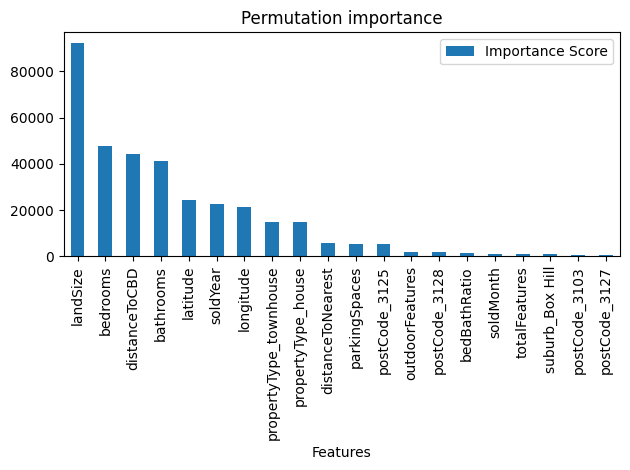

,Features,Importance Score
0,landSize,92282.665625
1,bedrooms,47891.803125
2,distanceToCBD,44313.281250
3,bathrooms,41280.343750
4,latitude,24357.634375
5,soldYear,22622.293750
6,longitude,21463.943750
7,propertyType_townhouse,14771.634375
8,propertyType_house,14659.834375
9,distanceToNearest,5520.378125


In [ ]:
perm = permutation_importance(best_xgb, X_test_pre, y_test,
                                scoring="neg_mean_absolute_error",
                                n_repeats=10, random_state=42, n_jobs=-1)
perm_series = pd.Series(perm.importances_mean, index=X_train_pre.columns).sort_values(ascending=False)
importance_df = perm_series.reset_index()
importance_df.columns = ['Features', 'Importance Score']
importance_df['Importance Score'] = importance_df['Importance Score'].astype(float).round(6)

plt.figure(figsize=(8,6))
importance_df.head(20).plot.bar(x='Features', y='Importance Score')
plt.title("Permutation importance")
plt.tight_layout()
plt.show()

display(importance_df.head(10).round(6))

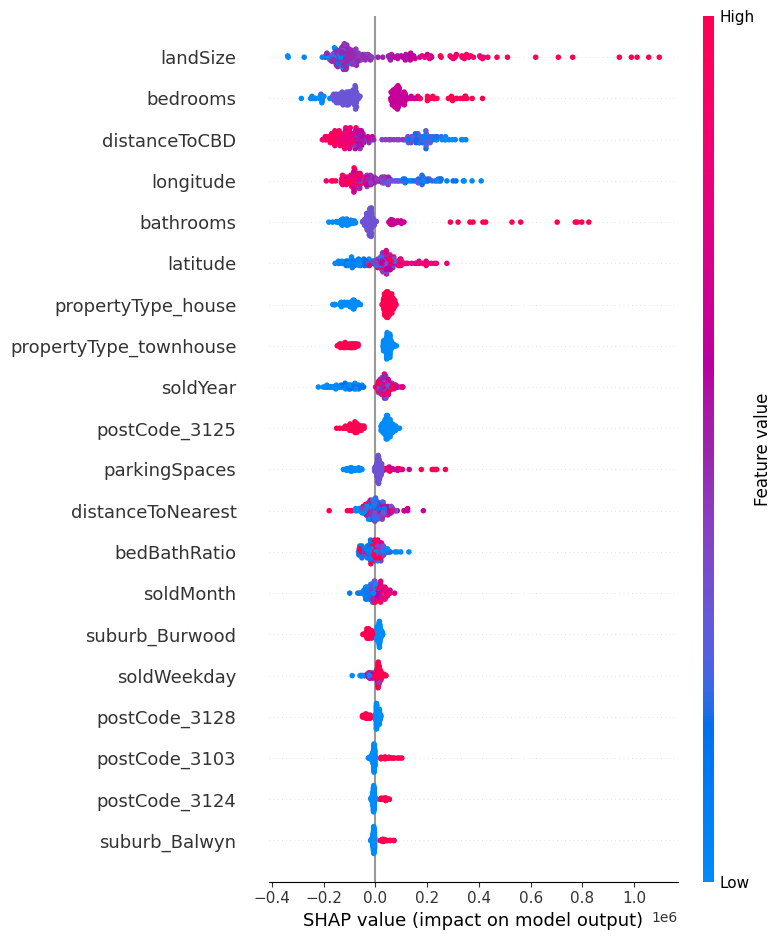

In [ ]:
shap.initjs()
# KernelExplainer is slower; use a small background sample
explainer = shap.TreeExplainer(best_xgb)

# use a subset for speed if dataset is large
sample_idx = np.random.RandomState(42).choice(len(X_test_pre), size=min(200, len(X_test_pre)), replace=False)
X_shap = X_test_pre.iloc[sample_idx]
shap_values = explainer.shap_values(X_shap)
shap.summary_plot(shap_values, X_shap, show=True)

In [162]:
if isinstance(shap_values, list):
    arr = shap_values[0]
else:
    arr = np.asarray(shap_values)

mean_abs_shap = np.mean(np.abs(arr), axis=0)
shap_imp = pd.Series(mean_abs_shap, index=X_shap.columns).sort_values(ascending=False)

display(shap_imp.head(20).round(6))

landSize                  177635.781250
bedrooms                  133826.796875
distanceToCBD             130461.890625
longitude                  95605.187500
bathrooms                  89845.476562
latitude                   66070.523438
propertyType_house         64539.605469
propertyType_townhouse     63153.148438
soldYear                   61813.761719
postCode_3125              60567.101562
parkingSpaces              40340.500000
distanceToNearest          30974.894531
bedBathRatio               22849.062500
soldMonth                  21627.144531
suburb_Burwood             19203.716797
soldWeekday                17083.658203
postCode_3128              13327.351562
postCode_3103              12432.552734
postCode_3124              11874.313477
suburb_Balwyn              10850.616211
dtype: float32

### Storing the model using pickle

In [152]:
with open('best_xgb_model.pkl', 'wb') as f:
    pickle.dump(best_xgb, f)

In [163]:
# Storing the Feature Importances
importance_df['Importance Score'] = importance_df['Importance Score'].round(4)
importance_df.to_excel("feature_importance.xlsx")

### Streamlit app

#### Additional libraries

In [ ]:
import streamlit as st
import numpy as np
import pandas as pd
import pickle
import plotly.express as px

#### Gathering user input

In [ ]:
# Funtion to gather all of our data
def get_user_input():
    st.sidebar.header("Property details")
    propertyType = st.sidebar.selectbox("Property Type", ["house", "townhouse", "other"])
    suburb = st.sidebar.text_input("Suburb", value="")
    postCode = st.sidebar.text_input("Postcode", value="")
    bedrooms = st.sidebar.number_input("Bedrooms", min_value=0, value=3, step=1)
    bathrooms = st.sidebar.number_input("Bathrooms", min_value=0, value=1, step=1)
    parkingSpaces = st.sidebar.number_input("Parking spaces", min_value=0, value=1, step=1)
    landSize = st.sidebar.number_input("Land size (sqm)", min_value=0.0, value=200.0, step=1.0, format="%.1f")
    indoorFeatures = st.sidebar.number_input("Indoor features", min_value=0, value=0, step=1)
    outdoorFeatures = st.sidebar.number_input("Outdoor features", min_value=0, value=0, step=1)
    latitude = st.sidebar.text_input("Latitude", value="")
    longitude = st.sidebar.text_input("Longitude", value="")

    user_data = {
        "propertyType": propertyType,
        "suburb": suburb.strip(),
        "postCode": postCode.strip(),
        "bedrooms": int(bedrooms),
        "bathrooms": int(bathrooms),
        "parkingSpaces": int(parkingSpaces),
        "landSize": float(landSize),
        "indoorFeatures": int(indoorFeatures),
        "outdoorFeatures": int(outdoorFeatures),
        "totalFeatures": int(indoorFeatures) + int(outdoorFeatures),
        "latitude": float(latitude) if str(latitude).strip() != "" else np.nan,
        "longitude": float(longitude) if str(longitude).strip() != "" else np.nan,
    }
    return user_data



#### Transforming user input data

In [ ]:
# Transform the input into the required format
def prepare_input(data, feature_list):
    # accept either a dict-like user_data or a single-row DataFrame
    if isinstance(data, pd.DataFrame):
        row = data.iloc[0].to_dict()
    else:
        row = dict(data or {})

    # small haversine helper (km)
    def haversine_km(lat1, lon1, lat2, lon2):
        R = 6371.0
        lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
        dlat = lat2 - lat1
        dlon = lon2 - lon1
        a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
        return R * 2 * np.arcsin(np.sqrt(a))

    # CBD coords (same as used in notebook)
    cbd_lat, cbd_lon = -37.810272, 144.962646

    # read basic values with safe defaults
    prop = str(row.get("propertyType", "")).strip().lower()
    pc = str(row.get("postCode", "")).strip()
    suburb = str(row.get("suburb", "")).strip()

    def to_float(v):
        try:
            return float(v)
        except Exception:
            return np.nan

    def to_int(v, default=0):
        try:
            return int(v)
        except Exception:
            return default

    fr = {}
    fr["landSize"] = to_float(row.get("landSize", np.nan))
    fr["latitude"] = to_float(row.get("latitude", np.nan))
    fr["longitude"] = to_float(row.get("longitude", np.nan))
    fr["bedrooms"] = to_int(row.get("bedrooms", 0), 0)
    fr["bathrooms"] = to_int(row.get("bathrooms", 0), 0)
    fr["parkingSpaces"] = to_int(row.get("parkingSpaces", 0), 0)
    fr["outdoorFeatures"] = to_int(row.get("outdoorFeatures", 0), 0)
    fr["indoorFeatures"] = to_int(row.get("indoorFeatures", 0), 0)
    # totalFeatures prefer provided, else sum indoor/outdoor
    if row.get("totalFeatures") is not None:
        fr["totalFeatures"] = to_int(row.get("totalFeatures"), fr["indoorFeatures"] + fr["outdoorFeatures"])
    else:
        fr["totalFeatures"] = fr["indoorFeatures"] + fr["outdoorFeatures"]

    # one-hot property types (keep same three used in training features)
    fr["propertyType_house"] = 1 if prop == "house" else 0
    fr["propertyType_other"] = 1 if prop == "other" else 0
    fr["propertyType_townhouse"] = 1 if prop == "townhouse" else 0

    # postcode one-hot keys used in training
    postcode_keys = ["3103", "3124", "3125", "3127", "3128"]
    for p in postcode_keys:
        fr[f"postCode_{p}"] = 1 if pc == p else 0

    # suburb one-hot keys used in training (match case-insensitive)
    suburb_keys = ["Balwyn", "Box Hill", "Burwood", "Camberwell", "Surrey Hills"]
    for s in suburb_keys:
        fr[f"suburb_{s}"] = 1 if suburb.lower() == s.lower() else 0

    # date-derived features
    ds = row.get("dateSold", None)
    if ds is None or (isinstance(ds, float) and np.isnan(ds)):
        ds_ts = pd.Timestamp.today()
    else:
        ds_ts = pd.to_datetime(ds, errors="coerce")
        if pd.isna(ds_ts):
            ds_ts = pd.Timestamp.today()
    fr["soldYear"] = int(ds_ts.year)
    fr["soldMonth"] = int(ds_ts.month)
    fr["soldWeekday"] = int(ds_ts.weekday())

    # distances
    if not pd.isna(fr["latitude"]) and not pd.isna(fr["longitude"]):
        fr["distanceToCBD"] = haversine_km(fr["latitude"], fr["longitude"], cbd_lat, cbd_lon)
    else:
        fr["distanceToCBD"] = np.nan
    # distanceToNearest requires dataset coordinates -> leave NaN for now
    fr["distanceToNearest"] = np.nan

    # bedBathRatio (handle divide-by-zero)
    fr["bedBathRatio"] = fr["bedrooms"] / fr["bathrooms"] if fr["bathrooms"] > 0 else 0.0

    # ensure all features in feature_list exist in the final dict (fill sensible defaults)
    for f in feature_list:
        if f not in fr:
            # numeric defaults 0 except distances -> nan
            if "distance" in f:
                fr[f] = np.nan
            elif f.startswith(("propertyType_", "postCode_", "suburb_")):
                fr[f] = 0
            else:
                fr[f] = 0

    # return a single-row DataFrame with columns in the given order
    out_df = pd.DataFrame([fr], columns=feature_list)
    return out_df

# Feature list (same order as used during model training)
features = [
    'landSize', 'latitude', 'longitude', 'bedrooms', 'bathrooms', 'parkingSpaces',
    'outdoorFeatures', 'indoorFeatures', 'totalFeatures',
    'propertyType_house', 'propertyType_other', 'propertyType_townhouse',
    'postCode_3103', 'postCode_3124', 'postCode_3125', 'postCode_3127', 'postCode_3128',
    'suburb_Balwyn', 'suburb_Box Hill', 'suburb_Burwood', 'suburb_Camberwell', 'suburb_Surrey Hills',
    'distanceToCBD', 'distanceToNearest', 'soldYear', 'soldMonth', 'soldWeekday', 'bedBathRatio'
]

#### Making predictions

In [ ]:
# prediction
prediction = best_xgb.predict(input_array)
prediction

#### Creating bar chart of feature importance

In [ ]:
# creating our Bar chart

# Sort feature importance DataFrame by 'Feature Importance Score'
importance_sorted = importance_df.sort_values(by='Importance Score', ascending=True)

# Create interactive bar chart with Plotly
fig = px.bar(
    importance_sorted,
    x='Importance Score',
    y='Features',
    orientation='h',
    title="Feature Importance",
    labels={'Importance Score': 'Importance', 'Features': 'Features'},
    text='Importance Score',
    color_discrete_sequence=['#48a3b4']  # Custom bar color
)
fig.update_layout(
    xaxis_title="Feature Importance Score",
    yaxis_title="Features",
    template="plotly_white",
    height=500
)
# st.plotly_chart(fig, use_container_width=True)

fig.show()

#### Creating apps

In [ ]:
import streamlit as st
import numpy as np
import pandas as pd
import pickle
import plotly.express as px

# Page configuration
st.set_page_config(layout="wide")

# Load your pre-trained model
with open('best_xgb_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

# Load feature importance from an Excel file
def load_feature_importance(file_path):
    return pd.read_excel(file_path)

# Load the feature importance DataFrame
importance_df = load_feature_importance("feature_importance.xlsx")  # Replace with your file path

def get_user_input():
    st.sidebar.header("Property details")
    propertyType = st.sidebar.selectbox("Property Type", ["house", "townhouse", "other"])
    suburb = st.sidebar.text_input("Suburb", value="")
    postCode = st.sidebar.text_input("Postcode", value="")
    bedrooms = st.sidebar.number_input("Bedrooms", min_value=0, value=3, step=1)
    bathrooms = st.sidebar.number_input("Bathrooms", min_value=0, value=1, step=1)
    parkingSpaces = st.sidebar.number_input("Parking spaces", min_value=0, value=1, step=1)
    landSize = st.sidebar.number_input("Land size (sqm)", min_value=0.0, value=200.0, step=1.0, format="%.1f")
    indoorFeatures = st.sidebar.number_input("Indoor features", min_value=0, value=0, step=1)
    outdoorFeatures = st.sidebar.number_input("Outdoor features", min_value=0, value=0, step=1)
    latitude = st.sidebar.text_input("Latitude", value="")
    longitude = st.sidebar.text_input("Longitude", value="")

    user_data = {
        "propertyType": propertyType,
        "suburb": suburb.strip(),
        "postCode": postCode.strip(),
        "bedrooms": int(bedrooms),
        "bathrooms": int(bathrooms),
        "parkingSpaces": int(parkingSpaces),
        "landSize": float(landSize),
        "indoorFeatures": int(indoorFeatures),
        "outdoorFeatures": int(outdoorFeatures),
        "totalFeatures": int(indoorFeatures) + int(outdoorFeatures),
        "latitude": float(latitude) if str(latitude).strip() != "" else np.nan,
        "longitude": float(longitude) if str(longitude).strip() != "" else np.nan,
    }
    return user_data

# Sidebar setup
st.sidebar.header('Housing Features')

# Centered title
st.markdown("<h1 style='text-align: center;'>Melbourne Housing Price Prediction App</h1>", unsafe_allow_html=True)

# Split layout into two columns
left_col, right_col = st.columns(2)

# Left column: Feature Importance Interactive Bar Chart
with left_col:
    st.header("Feature Importance")

    # Sort feature importance DataFrame by 'Importance Score'
    importance_sorted = importance_df.sort_values(by='Importance Score', ascending=True)
    
    # Create interactive bar chart with Plotly
    fig = px.bar(
        importance_sorted,
        x='Importance Score',
        y='Features',
        orientation='h',
        title="Feature Importance",
        labels={'Importance Score': 'Importance', 'Features': 'Feature'},
        text='Importance Score',
        color_discrete_sequence=["#156371"]  # Custom bar color
    )
    fig.update_layout(
        xaxis_title="Feature Importance Score",
        yaxis_title="Features",
        template="plotly_white",
        height=600
    )
    st.plotly_chart(fig, use_container_width=True)

# Right column: Prediction Interface
with right_col:
    st.header("Predict Housing Price")
    
    # User inputs from sidebar
    user_data = get_user_input()

    def prepare_input(data, feature_list):
        # accept either a dict-like user_data or a single-row DataFrame
        if isinstance(data, pd.DataFrame):
            row = data.iloc[0].to_dict()
        else:
            row = dict(data or {})

        # small haversine helper (km)
        def haversine_km(lat1, lon1, lat2, lon2):
            R = 6371.0
            lat1, lon1, lat2, lon2 = map(np.radians, (lat1, lon1, lat2, lon2))
            dlat = lat2 - lat1
            dlon = lon2 - lon1
            a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
            return R * 2 * np.arcsin(np.sqrt(a))

        # CBD coords (same as used in notebook)
        cbd_lat, cbd_lon = -37.810272, 144.962646

        # read basic values with safe defaults
        prop = str(row.get("propertyType", "")).strip().lower()
        pc = str(row.get("postCode", "")).strip()
        suburb = str(row.get("suburb", "")).strip()

        def to_float(v):
            try:
                return float(v)
            except Exception:
                return np.nan

        def to_int(v, default=0):
            try:
                return int(v)
            except Exception:
                return default

        fr = {}
        fr["landSize"] = to_float(row.get("landSize", np.nan))
        fr["latitude"] = to_float(row.get("latitude", np.nan))
        fr["longitude"] = to_float(row.get("longitude", np.nan))
        fr["bedrooms"] = to_int(row.get("bedrooms", 0), 0)
        fr["bathrooms"] = to_int(row.get("bathrooms", 0), 0)
        fr["parkingSpaces"] = to_int(row.get("parkingSpaces", 0), 0)
        fr["outdoorFeatures"] = to_int(row.get("outdoorFeatures", 0), 0)
        fr["indoorFeatures"] = to_int(row.get("indoorFeatures", 0), 0)
        # totalFeatures prefer provided, else sum indoor/outdoor
        if row.get("totalFeatures") is not None:
            fr["totalFeatures"] = to_int(row.get("totalFeatures"), fr["indoorFeatures"] + fr["outdoorFeatures"])
        else:
            fr["totalFeatures"] = fr["indoorFeatures"] + fr["outdoorFeatures"]

        # one-hot property types (keep same three used in training features)
        fr["propertyType_house"] = 1 if prop == "house" else 0
        fr["propertyType_other"] = 1 if prop == "other" else 0
        fr["propertyType_townhouse"] = 1 if prop == "townhouse" else 0

        # postcode one-hot keys used in training
        postcode_keys = ["3103", "3124", "3125", "3127", "3128"]
        for p in postcode_keys:
            fr[f"postCode_{p}"] = 1 if pc == p else 0

        # suburb one-hot keys used in training (match case-insensitive)
        suburb_keys = ["Balwyn", "Box Hill", "Burwood", "Camberwell", "Surrey Hills"]
        for s in suburb_keys:
            fr[f"suburb_{s}"] = 1 if suburb.lower() == s.lower() else 0

        # date-derived features
        ds = row.get("dateSold", None)
        if ds is None or (isinstance(ds, float) and np.isnan(ds)):
            ds_ts = pd.Timestamp.today()
        else:
            ds_ts = pd.to_datetime(ds, errors="coerce")
            if pd.isna(ds_ts):
                ds_ts = pd.Timestamp.today()
        fr["soldYear"] = int(ds_ts.year)
        fr["soldMonth"] = int(ds_ts.month)
        fr["soldWeekday"] = int(ds_ts.weekday())

        # distances
        if not pd.isna(fr["latitude"]) and not pd.isna(fr["longitude"]):
            fr["distanceToCBD"] = haversine_km(fr["latitude"], fr["longitude"], cbd_lat, cbd_lon)
        else:
            fr["distanceToCBD"] = np.nan
        # distanceToNearest requires dataset coordinates -> leave NaN for now
        fr["distanceToNearest"] = np.nan

        # bedBathRatio (handle divide-by-zero)
        fr["bedBathRatio"] = fr["bedrooms"] / fr["bathrooms"] if fr["bathrooms"] > 0 else 0.0

        # ensure all features in feature_list exist in the final dict (fill sensible defaults)
        for f in feature_list:
            if f not in fr:
                # numeric defaults 0 except distances -> nan
                if "distance" in f:
                    fr[f] = np.nan
                elif f.startswith(("propertyType_", "postCode_", "suburb_")):
                    fr[f] = 0
                else:
                    fr[f] = 0

        # return a single-row DataFrame with columns in the given order
        out_df = pd.DataFrame([fr], columns=feature_list)
        return out_df

    # Feature list (same order as used during model training)
    features = [
        'landSize', 'latitude', 'longitude', 'bedrooms', 'bathrooms', 'parkingSpaces',
        'outdoorFeatures', 'indoorFeatures', 'totalFeatures',
        'propertyType_house', 'propertyType_other', 'propertyType_townhouse',
        'postCode_3103', 'postCode_3124', 'postCode_3125', 'postCode_3127', 'postCode_3128',
        'suburb_Balwyn', 'suburb_Box Hill', 'suburb_Burwood', 'suburb_Camberwell', 'suburb_Surrey Hills',
        'distanceToCBD', 'distanceToNearest', 'soldYear', 'soldMonth', 'soldWeekday', 'bedBathRatio'
    ]

    # Predict button
    if st.button("Predict"):
        input_array = prepare_input(user_data, features).values
        prediction = xgb_model.predict(input_array)
        st.subheader("Predicted Price")
        st.write(f"${prediction[0]:,.2f}")